# Appendix: Advanced Trading Features
**This notebook presents extra analyses for trading signals, including technical indicators (RSI, Moving Average, MACD) and financial news sentiment.**


In [2]:
# ========================
# Crypto News Fetch Script
# ========================
import requests
import pandas as pd

# ------- CONFIG -------
API_KEY = 'b7c51623bbaab424671a5477c36752469284a76c'   # <- <-- Insert your API key here
COINS = ['BTC', 'BCH', 'LINK', 'STETH']           # Main coins, can extend
LIMIT = 50                                        # Headlines per coin (adjust if needed)

# ------- FETCH -------
news_rows = []
for coin in COINS:
    print(f"Fetching news for {coin}...")
    url = f"https://cryptopanic.com/api/v1/posts/?auth_token={API_KEY}&currencies={coin}&public=true&limit={LIMIT}"
    resp = requests.get(url)
    if resp.status_code == 200:
        items = resp.json().get('results', [])
        for item in items:
            # Parse main fields
            headline = item['title']
            date = pd.to_datetime(item['published_at']).date()
            news_rows.append({'Date': str(date), 'Headline': headline, 'Coin': f"{coin}-USD"})
    else:
        print(f"Failed for {coin}: {resp.text}")

# ------- SAVE -------
news_df = pd.DataFrame(news_rows)
news_df.to_csv("crypto_news.csv", index=False)
print(f"\nSaved {len(news_df)} headlines to crypto_news.csv\n")
print(news_df.groupby("Coin").size())
print("\nSample:")
print(news_df.head(10))


Fetching news for BTC...
Fetching news for BCH...
Fetching news for LINK...
Fetching news for STETH...

Saved 49 headlines to crypto_news.csv

Coin
BCH-USD      9
BTC-USD     20
LINK-USD    20
dtype: int64

Sample:
         Date                                           Headline     Coin
0  2025-08-14  Wall Street Still Underrates Bitcoin’s True Po...  BTC-USD
1  2025-08-14  Binance Bitcoin Reserves Surge To 579,000 BTC ...  BTC-USD
2  2025-08-14  Billionaire Predicts Massive $600 Billion U.S....  BTC-USD
3  2025-08-14  Bitcoin and crypto market could surge higher d...  BTC-USD
4  2025-08-14  Strategy Makes It Official—Legal Name Switch H...  BTC-USD
5  2025-08-14  Ripple’s XRP Path to $10 Mapped Out as 414% Ra...  BTC-USD
6  2025-08-14  Wall Street Underestimates Bitcoin’s Capital V...  BTC-USD
7  2025-08-14  Crypto Price Prediction Today 14 August – XRP,...  BTC-USD
8  2025-08-14  Bessent backtracks, says Treasury committed to...  BTC-USD
9  2025-08-14  Trump-backed American Bitcoin 


Saved: sentiment_BTC-USD.csv (1 days)


/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_89685/1418277353.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coin_news['sentiment_score'] = coin_news['Headline'].apply(


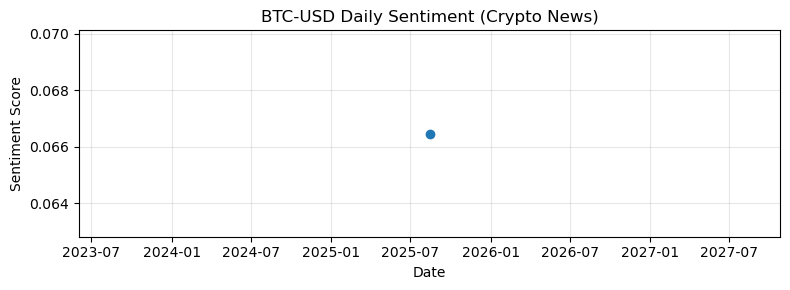


Saved: sentiment_BCH-USD.csv (5 days)


/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_89685/1418277353.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coin_news['sentiment_score'] = coin_news['Headline'].apply(


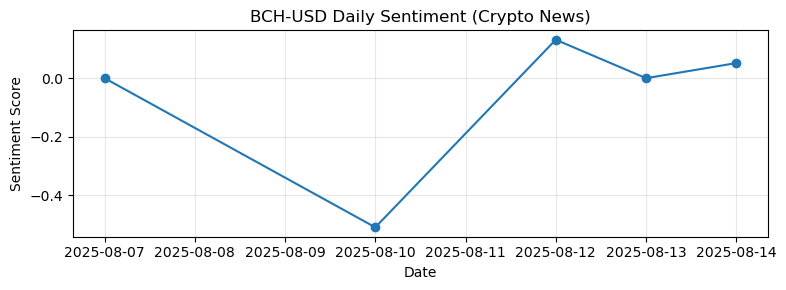

/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_89685/1418277353.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coin_news['sentiment_score'] = coin_news['Headline'].apply(



Saved: sentiment_LINK-USD.csv (2 days)


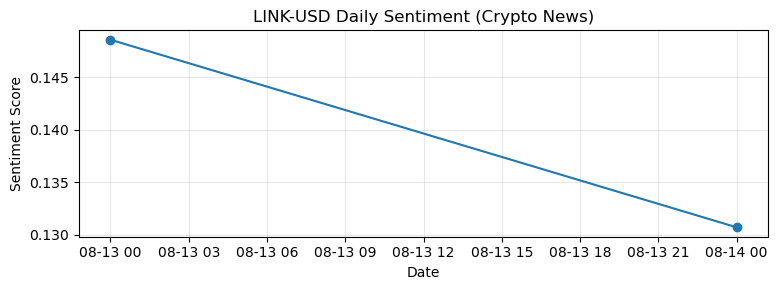


Saved: sentiment_STETH-USD.csv (0 days)


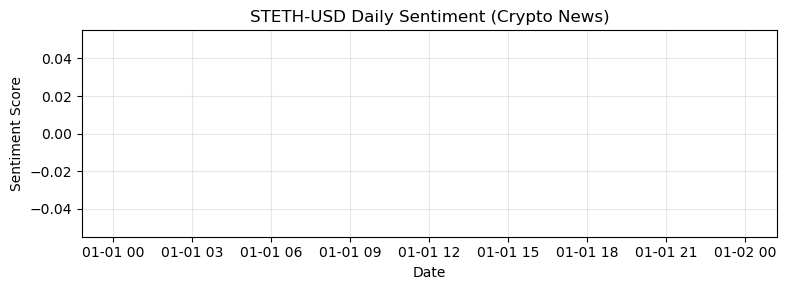

In [3]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

analyzer = SentimentIntensityAnalyzer()
# Load the news CSV
news_df = pd.read_csv("crypto_news.csv")
news_df['Date'] = pd.to_datetime(news_df['Date'])
COINS = ['BTC-USD', 'BCH-USD', 'LINK-USD', 'STETH-USD']

for coin in COINS:
    coin_news = news_df[news_df['Coin'].str.upper() == coin.upper()]
    # Assign sentiment score for each headline
    coin_news['sentiment_score'] = coin_news['Headline'].apply(
        lambda x: analyzer.polarity_scores(str(x))['compound']
    )
    # Group by date: average sentiment if multiple headlines per day
    sentiment_daily = coin_news.groupby('Date')['sentiment_score'].mean().reset_index()
    # Save per-coin daily sentiment CSV
    sentiment_daily.to_csv(f"sentiment_{coin}.csv", index=False)
    print(f"\nSaved: sentiment_{coin}.csv ({len(sentiment_daily)} days)")
    # Quick plot for quality check
    plt.figure(figsize=(8,3))
    plt.plot(sentiment_daily['Date'], sentiment_daily['sentiment_score'], marker='o')
    plt.title(f"{coin} Daily Sentiment (Crypto News)")
    plt.xlabel("Date"); plt.ylabel("Sentiment Score")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [4]:
import os
import pandas as pd

# === Configuration ===
MODEL_NAMES = ['arima', 'lstm', 'rf', 'xgb', 'prophet']
COINS = ['BTC-USD', 'BCH-USD', 'LINK-USD', 'STETH-USD']
PREDICT_DIR = "../results/Signal_Test/"
date_candidates = ['Date', 'date', 'timestamp', 'Timestamp', 'Test_Index', 'test_index']

fixed_files = []

for model in MODEL_NAMES:
    for coin in COINS:
        file_path = os.path.join(PREDICT_DIR, f"predictions_{model}_{coin}.csv")
        if not os.path.exists(file_path):
            print(f"[x] Missing prediction file: {file_path}")
            continue
        # Load and inspect columns
        df = pd.read_csv(file_path)
        col_names = [c.lower() for c in df.columns]
        # Determine the correct date column
        found_date_col = None
        for candidate in date_candidates:
            if candidate.lower() in col_names:
                found_date_col = [c for c in df.columns if c.lower() == candidate.lower()][0]
                break
        if found_date_col is None:
            print(f"[!] No recognized date column in {file_path}, skipping file.")
            continue
        # Rename to 'Date'
        if found_date_col != 'Date':
            df = df.rename(columns={found_date_col: 'Date'})
            print(f"[+] Renamed '{found_date_col}' to 'Date' in {file_path}")
        else:
            print(f"[✓] Date column already correct in {file_path}")
        # Optionally, parse as datetime for consistency
        try:
            df['Date'] = pd.to_datetime(df['Date'])
        except Exception as e:
            print(f"  [!] Could not parse 'Date' as datetime in {file_path}: {e}")
        # Save back to CSV
        df.to_csv(file_path, index=False)
        fixed_files.append(file_path)

print("\nAll prediction files now have a standardized 'Date' column!")
print(f"Files processed: {fixed_files}")


[✓] Date column already correct in ../results/Signal_Test/predictions_arima_BTC-USD.csv
[✓] Date column already correct in ../results/Signal_Test/predictions_arima_BCH-USD.csv
[✓] Date column already correct in ../results/Signal_Test/predictions_arima_LINK-USD.csv
[✓] Date column already correct in ../results/Signal_Test/predictions_arima_STETH-USD.csv
[+] Renamed 'Test_Index' to 'Date' in ../results/Signal_Test/predictions_lstm_BTC-USD.csv
[+] Renamed 'Test_Index' to 'Date' in ../results/Signal_Test/predictions_lstm_BCH-USD.csv
[+] Renamed 'Test_Index' to 'Date' in ../results/Signal_Test/predictions_lstm_LINK-USD.csv
[+] Renamed 'Test_Index' to 'Date' in ../results/Signal_Test/predictions_lstm_STETH-USD.csv
[✓] Date column already correct in ../results/Signal_Test/predictions_rf_BTC-USD.csv
[✓] Date column already correct in ../results/Signal_Test/predictions_rf_BCH-USD.csv
[✓] Date column already correct in ../results/Signal_Test/predictions_rf_LINK-USD.csv
[✓] Date column already co

In [9]:
import pandas as pd
import numpy as np
import os

MODEL_NAMES = ['arima', 'lstm', 'rf', 'xgb', 'prophet']
COINS = ['BTC-USD', 'BCH-USD', 'LINK-USD', 'STETH-USD']
PREDICT_DIR = "../results/Signal_Test/"
SENTIMENT_DIR = "./"

def enhanced_signal(row, threshold=0.2):
    if pd.isna(row['Actual']) or pd.isna(row['Predicted']):
        return "N/A"
    s = row.get('sentiment_score', np.nan)
    if pd.isna(s):  # sentiment missing, fallback to classic rule
        if row['Predicted'] > row['Actual']:
            return "Buy"
        elif row['Predicted'] < row['Actual']:
            return "Sell"
        else:
            return "Hold"
    # Sentiment logic
    if row['Predicted'] > row['Actual']:
        if s >= threshold:
            return "Strong Buy"
        elif s <= -threshold:
            return "Buy"
        else:
            return "Buy"
    elif row['Predicted'] < row['Actual']:
        if s <= -threshold:
            return "Strong Sell"
        elif s >= threshold:
            return "Sell"
        else:
            return "Sell"
    else:
        return "Hold"

results = []
for model in MODEL_NAMES:
    for coin in COINS:
        pred_path = os.path.join(PREDICT_DIR, f"predictions_{model}_{coin}.csv")
        sent_path = os.path.join(SENTIMENT_DIR, f"sentiment_{coin}.csv")
        if not os.path.exists(pred_path):
            print(f"[x] Missing predictions for {model.upper()} {coin}")
            continue
        pred_df = pd.read_csv(pred_path, parse_dates=['Date'])
        if os.path.exists(sent_path):
            sent_df = pd.read_csv(sent_path, parse_dates=['Date'])
        else:
            print(f"[x] Missing sentiment for {coin}, fallback to prediction signals.")
            sent_df = pd.DataFrame(columns=['Date', 'sentiment_score'])
        merged = pd.merge(pred_df, sent_df, on='Date', how='left')
        merged['Model'] = model.upper()
        merged['Coin'] = coin
        merged['EnhancedSignal'] = merged.apply(enhanced_signal, axis=1)
        results.append(merged)
        print(f"\n--- {model.upper()} {coin} ---")
        print(merged[['Date','Actual','Predicted','sentiment_score','EnhancedSignal']].head())

if results:
    all_signals = pd.concat(results, ignore_index=True)
    all_signals.to_csv("sentiment_enhanced_signals_all_models.csv", index=False)
    print("\nSaved: sentiment_enhanced_signals_all_models.csv")
    signal_table = all_signals.pivot_table(
        index=['Date','Coin'], columns='Model', values='EnhancedSignal', aggfunc='first'
    )
    print("\nSample signal table (last 10 rows):")
    print(signal_table.tail(10))
else:
    print("No merged results—check your files!")



--- ARIMA BTC-USD ---
        Date        Actual     Predicted  sentiment_score EnhancedSignal
0 2025-04-19  85063.414062  84450.804688              NaN           Sell
1 2025-04-20  85174.304688  84450.804688              NaN           Sell
2 2025-04-21  87518.906250  84450.804688              NaN           Sell
3 2025-04-22  93441.890625  84450.804688              NaN           Sell
4 2025-04-23  93699.109375  84450.804688              NaN           Sell

--- ARIMA BCH-USD ---
        Date      Actual   Predicted  sentiment_score EnhancedSignal
0 2025-04-19  335.330963  335.343933              NaN            Buy
1 2025-04-20  335.938873  335.343933              NaN           Sell
2 2025-04-21  344.806946  335.343933              NaN           Sell
3 2025-04-22  362.781738  335.343933              NaN           Sell
4 2025-04-23  358.217072  335.343933              NaN           Sell

--- ARIMA LINK-USD ---
        Date     Actual  Predicted  sentiment_score EnhancedSignal
0 2025-04-1

In [15]:
import sys
print("Python executable:", sys.executable)

import sys
print("Python version:", sys.version)

import os
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV', 'Not a conda env'))


Python executable: /opt/anaconda3/bin/python
Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
Conda environment: base
